<!-- colab-badge -->
[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/RemusTeodorescu/DL-for-Engineers-Public-Course/blob/main/exercises/Ex04-perceptron-to-mlp/Ex04_04_depth_vs_width_light.ipynb)

*Open this notebook in Google Colab. Its first code cell fetches the set's library files from the public course repository, so nothing needs uploading.*
*This is the **light** version: every TODO is written out, and you only replace the `...` marked lines with what the comment beside them says.*


<!-- course-header v3 -->

**Deep Learning for Engineering** · MSc, Aalborg University · 2026

Developed by **Remus Teodorescu** (ret@et.aau.dk), with support from Research Assistant **Noman Khan** (nomank@energy.aau.dk).

*Reference text — read for the theory. Used as an **inspirational source** for this course, not as a source of its code:*

- Prince, *Understanding Deep Learning*, MIT Press 2023.

Every notebook in this course has been **written and rewritten by the authors named above**. The code, the problems, the data and the exposition are **original to this course** and are not derived from any publisher's code listings or companion notebooks. Where notation matches a textbook's it is the standard notation of the field, and where an idea is a named author's it is cited as theirs in the text.

See `docs/PROVENANCE.md` for what each reference is cited for, set by set.

---

# Ex_04 · Notebook 04 — Depth Against Width, at Equal Budget

**Deep Learning for Engineering · Aalborg University · Part 1**

L4.2 slides 3 to 6 make an argument: composing layers multiplies the number of
linear regions a network can represent, where widening a single layer only adds
to it. The figure on slide 4 is a **prediction**. This notebook is the
**measurement**.

## The rule of the experiment

Comparing a big network with a small one tells you nothing you did not already
know. So fix the budget — about a thousand parameters — and spend it three ways:

| | shape | hidden layers |
| --- | --- | --- |
| **wide** | 1 → W → 1 | one, very wide |
| **middle** | 1 → W → W → 1 | two |
| **deep** | 1 → W → W → W → W → 1 | four, narrow |

Then train all three on the same data, with the same optimiser, for the same
number of epochs, from several seeds, and look at what you get.

## Two rules that make the answer trustworthy

**Several seeds, always.** You saw in notebook 02 that the same architecture can
succeed or fail depending only on its initialisation. A single run per
configuration would let you conclude anything you liked. Five runs per
configuration cost a minute and turn an anecdote into a measurement.

**Both curves, every run.** Training and validation loss go on the same pair of
axes, for every single run, without exception. This is a standing requirement of
the course. A configuration whose training loss is lowest and whose validation
loss is highest is not the winner, and the only way to see that is to plot both.

Expected runtime: two or three minutes for fifteen training runs.

---

## 0 · Setup

Four hundred training points and four hundred held-out points from the same
process — the same target as notebook 03, with more noise, because a capacity
comparison on noise-free data measures something else.

In [1]:
# files-cell v1 ----------------------------------------------------------
# This set's library files must sit beside the notebook. Locally they
# already do. On Google Colab, where a notebook opens on its own, they are
# fetched from the public course repository. Run this cell first.
import os, urllib.request
FILES = ['Ex_4_core.py']
URL = "https://raw.githubusercontent.com/RemusTeodorescu/DL-for-Engineers-Public-Course/main/exercises/Ex04-perceptron-to-mlp/"
for f in FILES:
    if not os.path.exists(f):
        urllib.request.urlretrieve(URL + f, f)
        print("fetched", f)
print("files ready:", ", ".join(FILES))


fetched Ex_4_core.py
files ready: Ex_4_core.py


In [2]:
# outputs-cell v1 --------------------------------------------------------
# Notebooks 03, 04 and 05 each save a results file that notebook 06 reads.
# On Google Colab every notebook runs on its own temporary machine, so a
# file saved here is not there when the next notebook opens. This cell
# keeps the results in your Google Drive instead: approve the access
# request when it appears. If you decline it, or have no Google Drive, the
# results are downloaded to your computer when saved and notebook 06 asks
# for them back. Locally this cell does nothing.
import Ex_4_core as core
core.keep_outputs()


Google Drive is not available (Error: credential propagation was unsuccessful).
Results will be downloaded to your computer instead. Keep the
files: the notebook that needs them asks for them.


'/content/Ex04_outputs'

train 400 points, validation 400 points
noise floor: 0.00360


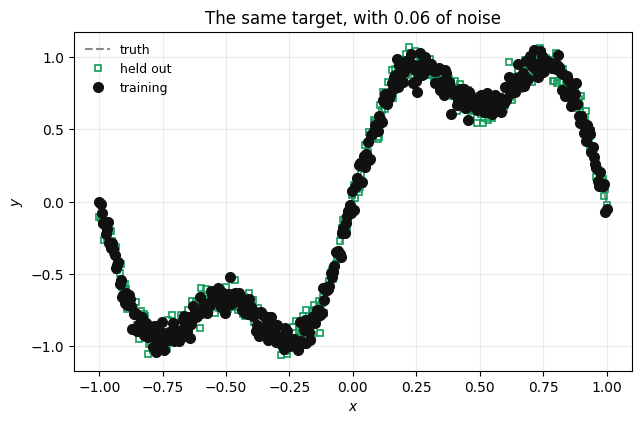

In [3]:
import os

import numpy as np
import matplotlib.pyplot as plt
import torch

import Ex_4_core as core

x_train, y_train = core.wiggly_dataset(n=400, noise=0.06, seed=7)
x_val, y_val = core.wiggly_dataset(n=400, noise=0.06, seed=8)
xs = np.linspace(-1.0, 1.0, 600)

NOISE_FLOOR = 0.06 ** 2
print(f"train {len(x_train)} points, validation {len(x_val)} points")
print(f"noise floor: {NOISE_FLOOR:.5f}")

core.plot_fit(x_train, y_train, x_val=x_val, y_val=y_val,
              truth=core.wiggly_truth, x_curve=xs,
              title="The same target, with 0.06 of noise")
plt.show()

**What you should see.** A noise floor of `0.00360`, and a figure in which the
black training markers and the green held-out markers are interleaved and
indistinguishable — which is the point of a held-out set drawn from the same
process. The target is the one from notebook 03, on $[-1, 1]$, with three times
the noise.

No model can do better than 0.0036 on either set. A validation loss at that level
is as good as it gets; a training loss *below* it means the model has started
fitting the noise in the training set specifically.

---

## 1 · Spending the budget

`core.parameter_count(n_in, hidden, n_out)` gives the parameter count of a shape
without building it. For a network with $K$ hidden layers of width $W$, one input
and one output:

$$ P \;=\; \underbrace{W + W}_{\text{first layer}}
   \;+\; \underbrace{(K-1)\,(W^2 + W)}_{\text{middle layers}}
   \;+\; \underbrace{W + 1}_{\text{output layer}} $$

which grows like $W$ for one hidden layer and like $K W^2$ for several. That is
already the reason the three shapes will have very different widths.

### Your turn

For each of $K = 1, 2, 4$ hidden layers, find the largest width $W$ whose
parameter count does not exceed the budget of 1000.

Search upwards from $W = 1$ — the counts are tiny and there is no reason to be
clever. Store the result as a list of `(name, hidden_tuple)` pairs.

In [9]:
BUDGET = 1000

# TODO 1 --- the widest network for each depth -------------------------------------------
# Two `...` to replace, inside widest():
#   line 1  ->  core.parameter_count(1, [W + 1] * K, 1)   the count one neuron wider
#   line 2  ->  W + 1                                     accept it while it fits
def widest(K):
    """The largest width W for K hidden layers of W neurons, within BUDGET parameters."""
    W = 1
    while core.parameter_count(1, [W + 1]*K, 1) <= BUDGET:                          # <- core.parameter_count(1, [W + 1] * K, 1)
        W = W + 1                                  # <- W + 1
    return W

configs = [(f"wide   1x{widest(1)}", (widest(1),) * 1),
           (f"middle 2x{widest(2)}", (widest(2),) * 2),
           (f"deep   4x{widest(4)}", (widest(4),) * 4)]
# ------------------------------------------------------------------------------

In [10]:
print(f"budget: {BUDGET} parameters\n")
for name, hidden in configs:
    p = core.parameter_count(1, list(hidden), 1)
    print(f"  {name:16s} hidden = {str(hidden):22s} parameters = {p:5d}"
          f"   ({100 * p / BUDGET:.0f} % of budget)")

budget: 1000 parameters

  wide   1x333     hidden = (333,)                 parameters =  1000   (100 % of budget)
  middle 2x29      hidden = (29, 29)               parameters =   958   (96 % of budget)
  deep   4x17      hidden = (17, 17, 17, 17)       parameters =   970   (97 % of budget)


**What you should see.** Three shapes, each within a few per cent of the budget:

- one hidden layer of **333** neurons — 1000 parameters,
- two hidden layers of **29** neurons — 958 parameters,
- four hidden layers of **17** neurons — 970 parameters.

Look at the widths before you look at any result. The shallow network is more
than *ten times* wider than the middle one and nearly twenty times wider than the
deep one, and all three cost the same. That is the whole reason depth is
interesting: a quadratic price for width in a layer, against a linear price for
another layer.

---

## 2 · The experiment

### Your turn

For each configuration and each seed in `range(5)`:

1. `core.set_seed(seed)`,
2. build `core.MLP(hidden=hidden, activation="relu")`,
3. train with `core.train(model, x_train, y_train, x_val=x_val, y_val=y_val,
   epochs=3000, lr=0.02, keep_best=True)`,
4. keep the history, the final training loss, and the best validation loss.

`keep_best=True` records the epoch with the lowest validation loss, which you
will need in notebook 05 and which is the honest number to compare here: it is
what early stopping would have given you.

Store everything in `runs`, a dictionary keyed by configuration name, each value
a list of five histories.

In [11]:
SEEDS = range(5)
EPOCHS = 3000

# TODO 2 --- three configurations, five seeds each ------------------------------------------
# Two `...` to replace, inside the loops:
#   line 1  ->  core.MLP(hidden=hidden, activation="relu")
#   line 2  ->  core.train(model, x_train, y_train, x_val=x_val, y_val=y_val,
#                          epochs=EPOCHS, lr=0.02, keep_best=True)
# Two or three minutes.
runs = {}
for name, hidden in configs:
    runs[name] = []
    for seed in SEEDS:
        core.set_seed(seed)
        model = core.MLP(hidden=hidden, activation="relu")                               # <- core.MLP(hidden=hidden, activation="relu")
        history = core.train(model, x_train, y_train, x_val=x_val, y_val=y_val, epochs=EPOCHS, lr=0.02, keep_best=True)                            # <- core.train(model, x_train, y_train, x_val=x_val, y_val=y_val, epochs=EPOCHS, lr=0.02, keep_best=True)
        runs[name].append(history)
        print(f"{name}  seed {seed}  train {history['train'][-1]:.5f}"
              f"  best val {history['best_val']:.5f} at epoch {history['best_epoch']}")
# ------------------------------------------------------------------------------

wide   1x333  seed 0  train 0.00293  best val 0.00396 at epoch 2878
wide   1x333  seed 1  train 0.00735  best val 0.00402 at epoch 2971
wide   1x333  seed 2  train 0.00285  best val 0.00396 at epoch 2738
wide   1x333  seed 3  train 0.00287  best val 0.00404 at epoch 2851
wide   1x333  seed 4  train 0.00301  best val 0.00422 at epoch 2986
middle 2x29  seed 0  train 0.00319  best val 0.00435 at epoch 1420
middle 2x29  seed 1  train 0.00343  best val 0.00419 at epoch 2911
middle 2x29  seed 2  train 0.00324  best val 0.00402 at epoch 2885
middle 2x29  seed 3  train 0.00304  best val 0.00402 at epoch 2884
middle 2x29  seed 4  train 0.00322  best val 0.00407 at epoch 2596
deep   4x17  seed 0  train 0.00709  best val 0.00768 at epoch 2830
deep   4x17  seed 1  train 0.00330  best val 0.00426 at epoch 2911
deep   4x17  seed 2  train 0.00302  best val 0.00403 at epoch 610
deep   4x17  seed 3  train 0.01545  best val 0.01100 at epoch 2071
deep   4x17  seed 4  train 0.00341  best val 0.00398 at ep

## 3 · Every run, both curves

Fifteen panels: one per run, training in blue and validation in red on the same
axes, with the best validation epoch marked.

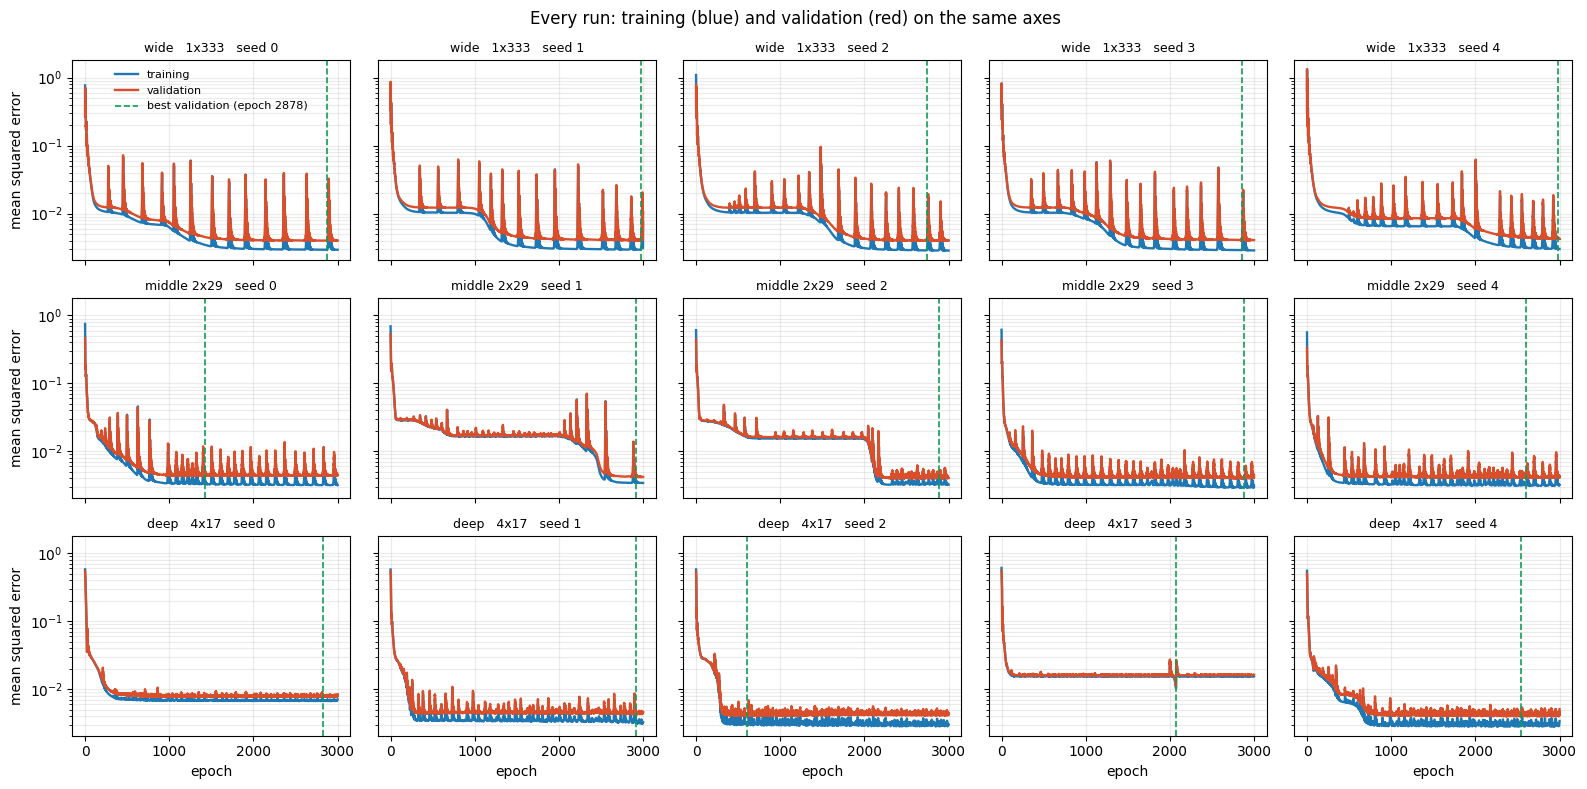

In [12]:
fig, axes = plt.subplots(len(configs), len(list(SEEDS)),
                         figsize=(16.0, 8.0), sharex=True, sharey=True)
for row, (name, _) in enumerate(configs):
    for col, history in enumerate(runs[name]):
        ax = axes[row, col]
        core.plot_curves(history, ax=ax, title="")
        ax.get_legend().remove()
        ax.set_title(f"{name}   seed {col}", fontsize=9)
        if col:
            ax.set_ylabel("")
        if row < len(configs) - 1:
            ax.set_xlabel("")
axes[0, 0].legend(frameon=False, fontsize=8)
fig.suptitle("Every run: training (blue) and validation (red) on the same axes",
             fontsize=12)
plt.tight_layout()
plt.show()

**What you should see.** Fifteen small plots, all of them falling steeply and
then flattening. In most panels the two curves stay close together; in some of
the larger models the blue curve slips below the red one late in the run and the
green dashed line — the best validation epoch — sits well before the end.

That separation is overfitting, appearing here in mild form because four hundred
points is a lot of data for a thousand parameters. Notebook 05 does it with
eleven points and it is not mild at all.

If one panel looks completely flat and much higher than the rest, that run failed
to train. **Report it rather than hiding it.** With ReLU neurons and a narrow deep
network it happens occasionally — neurons can end up switched off for every input
and receive no gradient thereafter — and it is one of the practical reasons deep
narrow networks are harder to train than the region-counting argument suggests.

---

## 4 · The measurement

In [13]:
rows = []
for name, hidden in configs:
    finals = np.array([h["train"][-1] for h in runs[name]])
    bests = np.array([h["best_val"] for h in runs[name]])
    epochs_best = np.array([h["best_epoch"] for h in runs[name]])
    rows.append([
        name,
        core.parameter_count(1, list(hidden), 1),
        f"{finals.mean():.5f} ± {finals.std():.5f}",
        f"{bests.mean():.5f} ± {bests.std():.5f}",
        f"{bests.min():.5f}",
        int(epochs_best.mean()),
    ])

print(core.error_table(rows, ["configuration", "parameters",
                              "final training MSE", "best validation MSE",
                              "best single seed", "mean best epoch"]))
print(f"\nnoise floor: {NOISE_FLOOR:.5f}")

| configuration | parameters | final training MSE | best validation MSE | best single seed | mean best epoch |
| --- | --- | --- | --- | --- | --- |
| wide   1x333 | 1000 | 0.00380 ± 0.00178 | 0.00404 ± 0.00010 | 0.00396 | 2884 |
| middle 2x29 | 958 | 0.00322 ± 0.00013 | 0.00413 ± 0.00013 | 0.00402 | 2539 |
| deep   4x17 | 970 | 0.00645 ± 0.00474 | 0.00619 ± 0.00278 | 0.00398 | 2192 |

noise floor: 0.00360


**What you should see.** Three rows in which the **best single seed** of each
configuration lands within about ten per cent of the others — typically 0.0039 to
0.0043, against a noise floor of 0.0036 — and in which the **means and spreads**
differ enormously.

Read that carefully, because it is the finding. At this budget, on this target,
no shape is meaningfully better than another when it trains successfully. What
differs is how reliably it trains: one configuration usually gives you nearly the
same number from every seed, and another gives you a good answer from two seeds
out of five and something three times worse from the rest.

A configuration whose mean is far above its minimum has failed runs in it. The
mean is then a bad summary — it is averaging two different populations — and the
right thing to report is the minimum, the number of successful runs, and the fact
that you counted.

The right shape of claim is therefore: *at this budget, on this target, with this
optimiser and this number of epochs, the three shapes reached best-seed validation
errors of X, Y and Z, which differ by less than the spread across seeds; the
shapes differed instead in how often training succeeded, which was A, B and C out
of five.* Every clause is doing work. Change any of them and the answer can
change.

---

## 5 · What the three shapes actually learned

Numbers compare; pictures explain. Plot the best seed of each configuration.

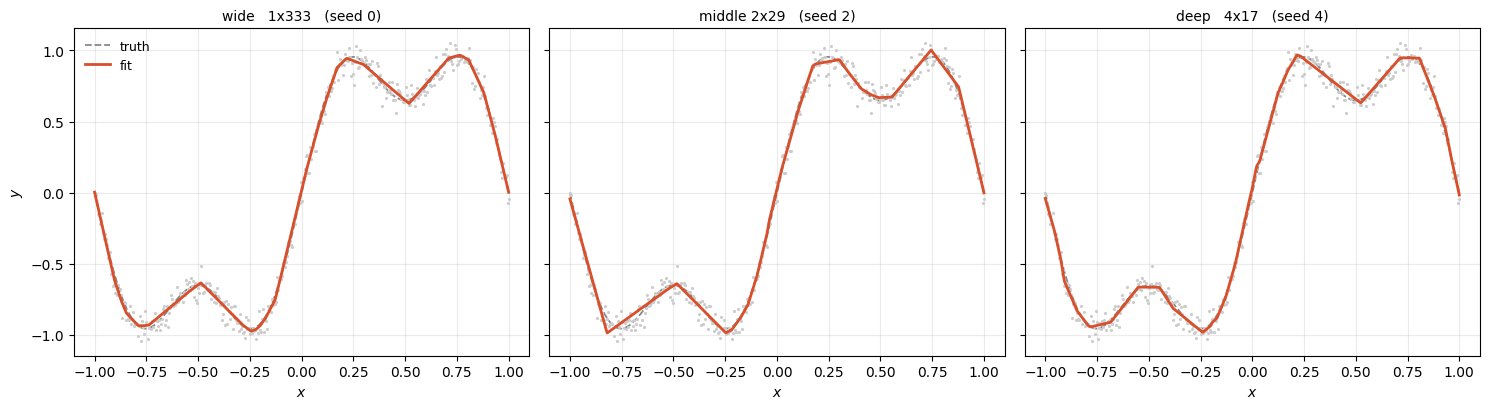

In [14]:
fig, axes = plt.subplots(1, len(configs), figsize=(15.0, 4.2), sharey=True)
for ax, (name, hidden) in zip(axes, configs):
    best_seed = int(np.argmin([h["best_val"] for h in runs[name]]))
    model = core.MLP(hidden=hidden, activation="relu")
    core.restore_best(model, runs[name][best_seed])
    ax.plot(xs, core.wiggly_truth(xs), lw=1.3, ls="--", color="#888888",
            label="truth")
    ax.plot(x_train, y_train, ".", ms=2.5, color="#cccccc")
    ax.plot(xs, core.predict(model, xs), lw=2.0, color="#d94f2b", label="fit")
    ax.set_title(f"{name}   (seed {best_seed})", fontsize=10)
    ax.set_xlabel("$x$")
    ax.grid(alpha=0.25)
axes[0].set_ylabel("$y$")
axes[0].legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

**What you should see.** Three fits that are all close to the truth, and all
still visibly piecewise linear if you look at the fine structure. The differences
between them are much smaller than the difference between any of them and the
$D = 3$ network in notebook 03, which is the comparison that puts this whole
notebook in proportion.

That is worth saying plainly: **at a thousand parameters, this problem is
saturated**. All three shapes can represent the target comfortably, so the
comparison is measuring optimisation and initialisation as much as
representational capacity. The region-counting argument on L4.2 slide 4 is about
what a shape *can* represent, and on a target this simple that ceiling is never
reached by any of the three.

If you want to see depth win on representation rather than on luck, you have to
make the target harder — more oscillations, or more input dimensions — or make
the budget much smaller. Try `BUDGET = 60` and run the notebook again if you
have time; the answer changes, and the reason it changes is the interesting part.

---

## 6 · Save the results

In [15]:
core.save_output("depth_vs_width.npz",
                 names=np.array([c[0] for c in configs]),
                 params=np.array([core.parameter_count(1, list(c[1]), 1) for c in configs]),
                 final_train=np.array([[h["train"][-1] for h in runs[c[0]]] for c in configs]),
                 best_val=np.array([[h["best_val"] for h in runs[c[0]]] for c in configs]))


saved: /content/Ex04_outputs/depth_vs_width.npz
This Colab machine is temporary, so the file(s) above are being downloaded. Keep them for the later notebooks.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

'/content/Ex04_outputs/depth_vs_width.npz'

## 7 · Before you move on

The first of these is the question that carries the marks in this notebook.

1. **At equal parameter count, which did better — deeper or wider? And why do you
   think so?** Give the numbers, the spreads, and one sentence of mechanism. If
   your honest answer is "the difference between the best runs is smaller than
   the spread across seeds, and what actually differed was reliability", say
   that; it is a better answer than a confident wrong one.
2. The shallow network was 333 neurons wide and the deep one 17. Explain, from the
   parameter formula, why the budget buys such different widths.
3. You trained every configuration for exactly 3000 epochs. Name one way that
   choice could have biased the comparison, and how you would remove the bias.
4. Suppose your supervisor asks for "the best model" from this notebook. Which
   number in the table would you quote, and which one would be misleading to
   quote?

*Write your answers here.*

1.
2.
3.
4.

---

Continue with **[`Ex04_05_overfit_then_regularise_light.ipynb`](https://colab.research.google.com/github/RemusTeodorescu/DL-for-Engineers-Public-Course/blob/main/exercises/Ex04-perceptron-to-mlp/Ex04_05_overfit_then_regularise_light.ipynb)**, which uses the eleven
points from the lecture.